### **Imports Iniciales**

In [14]:
import re, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# NLP clásico
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Representación y modelo
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neighbors import NearestNeighbors

# Remuestreo (para la evaluación de SMOTE)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from nltk.tokenize import word_tokenize, sent_tokenize

warnings.filterwarnings(action='ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
plt.style.use(style='seaborn-v0_8-whitegrid')

SEMILLA = 42
CLASES = ['negativo', 'neutral', 'positivo']
print('✓ Entorno listo')

✓ Entorno listo


Parte 1: carga de datos

In [4]:
train_raw = pd.read_csv('data/train.csv')
eval_raw = pd.read_csv('data/eval.csv')

display(train_raw.head())

,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


Parte 2: Calidad de datos

Para la verificación de la calidad de datos, se parte por la siguiente hipótesis: Que la columna *id* sea única no garantiza que los datos no lo sean, por lo que se va a verificar la **dimensiones de calidad** de las filas en dos niveles:

1. **Estructural:** *id* único, nulos, textos vacíos, etiquetas válidas. Esto quiere decir que en este nivel, se verificará la **unicidad**, **completitud** y **consistencia** en su forma "clásica".
2. **De contenido:** Textos repetidos (exactos y casi exactos) y, sobre todo, textos con **etiquetas distintas** (ruido de etiqueta). Es decir, se verificará la **unicidad** y **consistencia** de los datos.

Se hace esta verificación porque si una reseña duplicada cae en el fold de entrenamiento y en el de validación a la vez, la exactitud de validación se infla (data leakage) y elegiríamos hiperparámetros con una métrica optimista (sobreestima los datos).

In [6]:
def auditar(df, nombre, con_label=True):
    print(f'-- {nombre} --')
    print(f'Filas: {len(df):,}')
    print(f'Nulos por columna: {df.isna().sum().to_dict()}')
    print(f'IDs únicos: {df["id"].is_unique} (IDs repetidos: {df["id"].duplicated().sum()})')
    print(f'Textos vacíos o solo espacios: {df['text'].fillna("").str.strip().eq("").sum()}')
    if con_label:
        etiquetas = df["label"].astype(str).str.strip().str.lower()
        fuera = sorted(set(etiquetas) - set(CLASES))
        print(f'Etiquetas fuera de {CLASES}: {fuera if fuera else "ninguna"}')
        print(f'Etiquetas con espacios/Mayúsculas por corregir: {(etiquetas != df["label"]).sum()}')
    print()

auditar(train_raw, 'train')
auditar(eval_raw, 'eval', con_label = False)

-- train --
Filas: 12,000
Nulos por columna: {'id': 0, 'text': 0, 'label': 0}
IDs únicos: True (IDs repetidos: 0)
Textos vacíos o solo espacios: 0
Etiquetas fuera de ['negativo', 'neutral', 'positivo']: ninguna
Etiquetas con espacios/Mayúsculas por corregir: 0

-- eval --
Filas: 3,000
Nulos por columna: {'id': 0, 'text': 0}
IDs únicos: True (IDs repetidos: 0)
Textos vacíos o solo espacios: 0



In [7]:
#Se crea una columna auxiliar 'clave' "laxa" para comparar el parecido con 'text'

def clave_duplicado(s):
    #Estandariza espacios
    return s.fillna('').str.lower().str.replace(r'\s+', ' ', regex=True)

#Se hace una copia del dataset de entrenamiento como buena práctica
train = train_raw.copy()
train['label'] = train['label'].astype(str).str.strip().str.lower()
train['clave'] = clave_duplicado(train['text'])

grupos = train.groupby('clave')['label'].agg(['size', 'nunique'])
dup_mismo_label = grupos[(grupos['size'] > 1) & (grupos['nunique'] == 1)]
dup_conflicto = grupos[grupos['nunique'] > 1]

print(f'Duplicados exactos (texto crudo): {train["text"].duplicated().sum()}')
print(f'Duplicados por clave laxa: {train["clave"].duplicated().sum()}')
print(f'grupos con la misma etiqueta: {len(dup_mismo_label)} (filas sobrantes: {(dup_mismo_label["size"] - 1).sum()})')
print(f'Duplicados exactos (texto crudo): {len(dup_conflicto)} (filas involucradas: {dup_conflicto["size"].sum()})')

if len(dup_conflicto):
    display(train[train['clave'].isin(dup_conflicto.index)].sort_values('clave')[['id', 'text', 'label']].head(10))

#Unicamente se verifica si hay datos solapados entre datos de train y eval
solapamiento = set(train['clave']) & set(clave_duplicado(eval_raw['text']))
print(f'Textos de eval que también aparecen en train: {len(solapamiento)}')

Duplicados exactos (texto crudo): 0
Duplicados por clave laxa: 0
grupos con la misma etiqueta: 0 (filas sobrantes: 0)
Duplicados exactos (texto crudo): 0 (filas involucradas: 0)
Textos de eval que también aparecen en train: 0


In [8]:
n_inicial = len(train)
train = train[train['clave'] != '']
train = train[~train['clave'].isin(dup_conflicto.index)]
train = train.drop_duplicates(subset='clave', keep = 'first')
train = train.drop(columns='clave').reset_index(drop=True)

eval_df = eval_raw.copy()
eval_df['text'] = eval_df['text'].fillna('')

print(f'train: {n_inicial:,}: {len(train):,} filas (eliminadas: {n_inicial - len(train):,})')

train: 12,000: 12,000 filas (eliminadas: 0)


3. Exploracion rapida

- balanceo de clases
- longitud de reseñas
- Diferencia de palabras de negacion y contraste por clase (para no tratarlas como stop words)

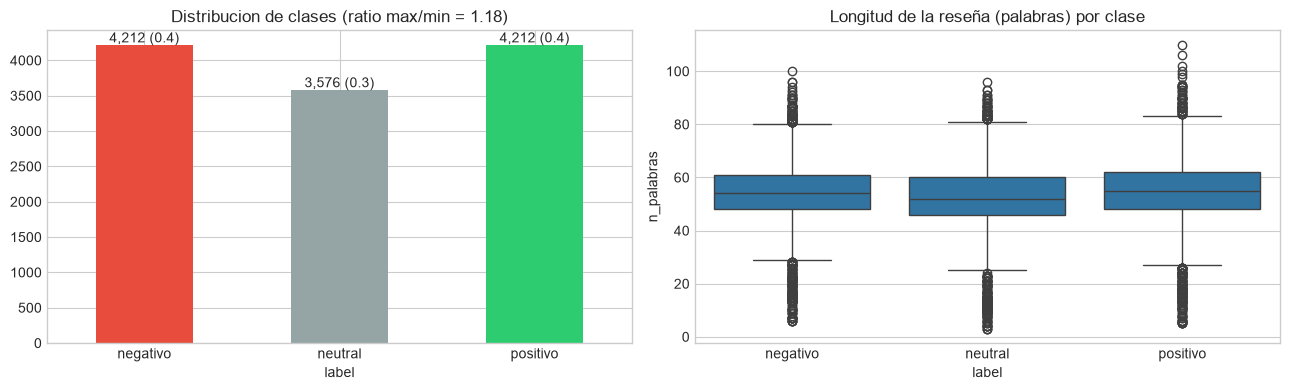

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


In [9]:
conteo = train['label'].value_counts().reindex(CLASES)
ratio_desbalance = conteo.max() / conteo.min()
train['n_palabras'] = train['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conteo.plot.bar(ax = axes[0], color = ['#E74C3C', '#95A5A6', '#2ECC71'], rot = 0)
axes[0].set_title(f'Distribucion de clases (ratio max/min = {ratio_desbalance:.2f})')
for i, v in enumerate(conteo):
    axes[0].text(i, v, f'{v:,} ({v / conteo.sum():.1f})', ha='center', va='bottom')
sns.boxplot(data=train, x='label', y='n_palabras', order=CLASES, ax=axes[1])
axes[1].set_title('Longitud de la reseña (palabras) por clase')
plt.tight_layout()
plt.show()

display(train.groupby('label')['n_palabras'].describe().reindex(CLASES).round(1))

In [11]:
# % de reseñas de cada clase que contienen el marcador
marcadores = ['no', 'nunca', 'nada', 'sin', 'pero', 'aunque', 'sin embargo', 'muy']
tabla = pd.DataFrame({
    m: train.groupby('label')['text'].apply(lambda s: s.str.lower().str.contains(rf'\b{m}\b', regex = True).mean() * 100) for m in marcadores
}).reindex(CLASES)
display(tabla.round(1))

PATRON_ESPECIALES = r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ0-9\s.,;:!?¡¿()\'"\-]'
otros = train['text'].str.findall(PATRON_ESPECIALES).explode().dropna()
pct_especiales = train['text'].str.contains(PATRON_ESPECIALES, regex=True).mean()
print(f'Reseñas con caracteres especiales: {pct_especiales:.1%}')
print('Más frecuentes: ', otros.value_counts().head(15).to_dict())

,no,nunca,nada,sin,pero,aunque,sin embargo,muy
label,,,,,,,,
negativo,27.1,0.2,18.3,23.4,9.5,4.9,1.5,10.8
neutral,40.6,0.1,27.3,27.7,3.7,2.7,0.0,0.2
positivo,25.9,0.2,16.5,23.4,3.8,3.9,1.4,8.2


Reseñas con caracteres especiales: 0.1%
Más frecuentes:  {'Ã': 24, '\xad': 16, '³': 4, '±': 3, '©': 3, 'ì': 3, 'è': 2, 'à': 2, 'º': 1, '%': 1, 'ò': 1}


duuuuuro, asi nos quieren enredar los profes aunque sea 0.1%

In [15]:
train['n_oraciones'] = train['text'].apply(lambda s: len(sent_tokenize(s, language = 'spanish')))
display(train.groupby('label')['n_oraciones'].describe().reindex(CLASES).round(2))
print(f'Reseñas con más de una oración: {(train["n_oraciones"] > 1).mean():.1%}')

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,3.85,0.79,1.0,3.0,4.0,4.0,7.0
neutral,3576.0,3.89,0.73,1.0,4.0,4.0,4.0,6.0
positivo,4212.0,3.93,0.78,1.0,4.0,4.0,4.0,7.0


Reseñas con más de una oración: 98.9%


4. Preprocesamiento adaptado a analisis de sentimiento

In [12]:
def sin_tildes(s):

    s = s.replace('ñ', '§')
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    return s.replace('§', 'ñ')

CONECTORES_MULTI = {'sin embargo': 'sin_embargo', 'no obstante': 'no_obstante', 'a pesar de': 'a_pesar_de'}
NEGADORES  = {'no', 'ni', 'nunca', 'jamas', 'tampoco', 'sin', 'nada', 'nadie', 'ningun', 'ninguno', 'ninguna'}
ADVERSATIVOS = {'pero', 'sin_embargo', 'no_obstante', 'sino'}
CONCESIVOS   = {'aunque', 'a_pesar_de'}
INTENSIDAD = {'muy', 'mas', 'menos', 'mucho', 'mucha', 'muchos', 'muchas', 'poco', 'poca', 'pocos', 'pocas',
              'tan', 'tanto', 'demasiado', 'bastante', 'algo', 'todo'}

PALABRAS_A_CONSERVAR = NEGADORES | ADVERSATIVOS | CONCESIVOS | INTENSIDAD
stop_nltk = {sin_tildes(w) for w in stopwords.words('spanish')}
STOPWORDS_SENTIMIENTO = stop_nltk - PALABRAS_A_CONSERVAR

print(f'Stopwords NLTK: {len(stop_nltk)}: personalizadas: {len(STOPWORDS_SENTIMIENTO)}')
print('Rescatadas de la lista de NLTK:', sorted(stop_nltk & PALABRAS_A_CONSERVAR))

Stopwords NLTK: 306: personalizadas: 293
Rescatadas de la lista de NLTK: ['algo', 'mas', 'mucho', 'muchos', 'muy', 'nada', 'ni', 'no', 'pero', 'poco', 'sin', 'tanto', 'todo']


In [ ]:
PALABRA_RE = re.compile(r'[a-záéíóúüñ_]+|\d+(?:[.,]\d+)?')
PUNTUACION = set('.,;:!?¡¿()') | {'...'}
stemmer = SnowballStemmer('spanish')
SUPERLATIVO_RE = re.compile(r'\b([a-záéíóúñ]{3,}?)[ií]sim[oa]s?\b')

def _superlativo(m):
    raiz = m.group(1)
    if raiz.endswith('qu'):
        raiz = raiz[:-2] + 'c'
    elif raiz.endswith('gu'):
        raiz = raiz[:-1]
    elif raiz.endswith('bil'):
        return f'muy {raiz[:-3]}ble'
    return f'muy {raiz}o'

def preprocesar(texto, stemming=True, quitar_tildes=True, negacion=True, ventana_neg=3, contraste=False, numeros='mantener'):

    if not isinstance(texto, str):
        return ''

    t = texto.lower()
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'([aeiouáéíóú])\1{2,}', r'\1', t)
    t = re.sub(r'(.)\1{2,}', r'\1\1', t)
    t = SUPERLATIVO_RE.sub(_superlativo, t)
    for frase, unido in CONECTORES_MULTI.items():
        t = re.sub(r'\b' + frase.replace(' ', r'\s+') + r'\b', unido, t)
    if numeros == 'eliminar':
        t = re.sub(r'\d+(?:[.,]\d+)?', ' ', t)
    elif numeros == 'token':
        t = re.sub(r'\d+(?:[.,]\d+)?', ' num ', t)
    t = re.sub(r'([¡¿])', r' \1 ', t)

    salida, neg_restante, idx_contraste = [], 0, -1
    for tok in word_tokenize(t, language='spanish'):
        if tok in PUNTUACION:
            neg_restante = 0
            continue
        tok = tok.rstrip('.')
        if not PALABRA_RE.fullmatch(tok):
            continue
        base = sin_tildes(tok)
        if base in STOPWORDS_SENTIMIENTO:
            continue
        if base in PALABRAS_A_CONSERVAR:
            forma = base
        elif  base[0].isdigit():
            forma = re.sub(r'[.,]', '_', base)
        else:
            forma = stemmer.stem(tok) if stemming else tok
            if quitar_tildes:
                forma = sin_tildes(forma)
            if negacion and neg_restante > 0:
                forma = 'neg' + forma
                neg_restante -= 1

        if base in ADVERSATIVOS or base in CONCESIVOS:
            neg_restante = 0
        if negacion and base in NEGADORES:
            neg_restante = ventana_neg

        salida.append(forma)
        if base in ADVERSATIVOS:
            idx_contraste = len(salida)


    if contraste and idx_contraste >= 0:
        salida = salida[:idx_contraste + 1] + ['tras_' + w for w in salida[idx_contraste + 1:]]
    return ' '.join(salida)



La siguiente celda es unicamente de prueba para ver si el punkt si esta funcionando como se espera, entonces se puede borrar :D

In [16]:
for s in ['No lo recomiendo, etc. Nunca más!!!', '¿Vale la pena? No, cuesta 4.5 millones.']:
    print(s)
    print('  split()       →', s.lower().split())
    print('  word_tokenize →', word_tokenize(re.sub(r'([¡¿])', r' \1 ', s.lower()), language='spanish'))
    print()

No lo recomiendo, etc. Nunca más!!!
  split()       → ['no', 'lo', 'recomiendo,', 'etc.', 'nunca', 'más!!!']
  word_tokenize → ['no', 'lo', 'recomiendo', ',', 'etc.', 'nunca', 'más', '!', '!', '!']

¿Vale la pena? No, cuesta 4.5 millones.
  split()       → ['¿vale', 'la', 'pena?', 'no,', 'cuesta', '4.5', 'millones.']
  word_tokenize → ['¿', 'vale', 'la', 'pena', '?', 'no', ',', 'cuesta', '4.5', 'millones', '.']



#### PIPELINE: funcion de limpieza completa

In [ ]:
_porter, _stop_es = nltk.PorterStemmer(), set(stopwords.words('spanish'))
def limpiar_texto_clase(texto):
    #Normalizacion
    texto = re.sub(r'[^\w\s]', '', texto.lower())
    texto = re.sub(r'\d+', '', texto)  # eliminar números
    tokens = [t for t in texto.split() if t not in _stop_es and len(t) > 2]
    return ' '.join(_porter.stem(t) for t in tokens)

In [19]:
#Se generan las variantes como columnas para comparar al vectorizar/modelar

VARIANTES = {
    'texto_base': dict(negacion = False),
    'texto_neg': dict(negacion = True),
    'texto_neg_contraste': dict(negacion=True, contraste=True)
}

for col,kwargs in VARIANTES.items():
    train[col] = train['text'].apply(preprocesar, **kwargs)
    eval_df[col] = eval_df['text'].apply(preprocesar, **kwargs)

def tam_vocabulario(serie):
    return len(set(' '.join(serie).split()))

vocab_crudo = tam_vocabulario(train['text'].str.lower().str.replace(r'[^\w\s]', ' ', regex=True))
print(f'Vocabulario crudo: {vocab_crudo:,}')
for col in VARIANTES:
    v = tam_vocabulario(train[col])
    print(f'{col:22s}: {v:,} ({v / vocab_crudo - 1:+.1%} respecto al crudo)')

vacios = (train['texto_neg'].str.strip() == '').sum()
print(f'\nReseñas que quedaron vacías tras la limpieza: {vacios}')

Vocabulario crudo: 6,054
texto_base            : 3,067 (-49.3% respecto al crudo)
texto_neg             : 3,898 (-35.6% respecto al crudo)
texto_neg_contraste   : 4,692 (-22.5% respecto al crudo)

Reseñas que quedaron vacías tras la limpieza: 0
